In [1]:
# ================================================================
# CELL 1: Imports & Setup
# ================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import linregress

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Plot theme constants ──
DARK_BG   = '#090C10'
PANEL_BG  = '#0D1117'
GRID_COL  = '#21262D'
TICK_COL  = '#8B949E'
TEXT_COL  = '#CDD9E5'
TITLE_COL = '#E6EDF3'

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TICK_COL, which='both', labelsize=8.5)
    ax.set_xlabel(xlabel, fontsize=10, color=TICK_COL, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=10, color=TICK_COL, labelpad=8)
    ax.set_title(title, fontsize=11, color=TITLE_COL, pad=10, fontweight='bold')
    ax.grid(True, which='major', linestyle='-',  linewidth=0.45, color=GRID_COL)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.25, color=GRID_COL)
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363D')

print("Imports done.")

Device: cuda
GPU:    Tesla T4
VRAM:   15.6 GB
Imports done.


In [2]:
# ================================================================
# CELL 2: TinyVGG Model Definition
# ================================================================
class TinyVGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),  # conv1_1
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),  # conv1_2
            nn.MaxPool2d(2, 2),                                                              # 32→16
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),  # conv2_1
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),  # conv2_2
            nn.MaxPool2d(2, 2),                                                              # 16→8
            # Block 3
            nn.Conv2d(64, 128,3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),  # conv3_1
            nn.Conv2d(128,128,3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),  # conv3_2
            nn.MaxPool2d(2, 2),                                                              # 8→4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# ── Receptive field per conv layer ──
def tiny_vgg_rf():
    arch = [
        ('conv',3,1),('conv',3,1),('pool',2,2),
        ('conv',3,1),('conv',3,1),('pool',2,2),
        ('conv',3,1),('conv',3,1),('pool',2,2),
    ]
    rf, stride = 1, 1
    names, rfs = [], []
    blk, bidx  = 1, 1
    for t, k, s in arch:
        if t == 'pool':
            rf += (k-1)*stride; stride *= s; blk += 1; bidx = 1
        else:
            rf += (k-1)*stride
            names.append(f"conv{blk}_{bidx}"); rfs.append(rf); bidx += 1
    return names, rfs

LAYER_NAMES, RECEPTIVE_FIELDS = tiny_vgg_rf()
INV_RF    = np.array([1.0/r for r in RECEPTIVE_FIELDS])
N_LAYERS  = len(LAYER_NAMES)

print("Layer    RF    1/L")
print("─"*28)
for n, r in zip(LAYER_NAMES, RECEPTIVE_FIELDS):
    print(f"{n:10s}  {r:4d}   {1/r:.5f}")

Layer    RF    1/L
────────────────────────────
conv1_1        3   0.33333
conv1_2        5   0.20000
conv2_1       10   0.10000
conv2_2       14   0.07143
conv3_1       24   0.04167
conv3_2       32   0.03125


In [3]:
# ================================================================
# CELL 3: CIFAR-10 DataLoaders
# ================================================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2023,0.1994,0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2023,0.1994,0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
testloader  = torch.utils.data.DataLoader(
    testset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(trainloader)}")
print(f"Test  batches : {len(testloader)}")
print(f"Train samples : {len(trainset)}")
print(f"Test  samples : {len(testset)}")

100%|██████████| 170M/170M [00:14<00:00, 11.9MB/s]


Train batches : 196
Test  batches : 40
Train samples : 50000
Test  samples : 10000


In [4]:
# ================================================================
# CELL 4: Shannon Entropy + Collection Helpers
# ================================================================

def shannon_entropy(weights: np.ndarray, bins: int = 100) -> float:
    """
    Histogram-based Shannon entropy of weight values.
    H = -Σ p(w) · log(p(w))   [nats]

    Steps:
      1. Build histogram of weight values into `bins` buckets
      2. Convert counts → probabilities
      3. Compute H = -Σ p·log(p)

    Example:
      weights = [-0.3, 0.0, 0.0, 0.3, 0.3]
      bins    = [-0.4,-0.1) → 1 count
                [-0.1, 0.2) → 2 counts
                [ 0.2, 0.5) → 2 counts
      p       = [0.2, 0.4, 0.4]
      H       = -(0.2·ln0.2 + 0.4·ln0.4 + 0.4·ln0.4) = 1.055 nats
    """
    counts, _ = np.histogram(weights, bins=bins, density=False)
    counts    = counts[counts > 0].astype(float)
    probs     = counts / counts.sum()
    return float(-np.sum(probs * np.log(probs + 1e-12)))


def collect_metrics(model):
    """
    For each Conv2d layer collect:
      - Shannon entropy of weights
      - Sum of squares of weights
    Returns (entropy_list, sum_sq_list)
    """
    entropy_list = []
    sum_sq_list  = []
    for m in model.features:
        if isinstance(m, nn.Conv2d):
            w = m.weight.detach().cpu().numpy().flatten()
            entropy_list.append(shannon_entropy(w))
            sum_sq_list.append(float((w**2).sum()))
    return entropy_list, sum_sq_list


# Quick sanity check
_tmp = TinyVGG()
_e, _s = collect_metrics(_tmp)
print("Sanity check on random init model:")
print(f"{'Layer':>10}  {'Entropy':>8}  {'SumSq':>12}")
print("─"*35)
for n, e, s in zip(LAYER_NAMES, _e, _s):
    print(f"{n:>10}  {e:>8.4f}  {s:>12.4f}")
del _tmp, _e, _s

Sanity check on random init model:
     Layer   Entropy         SumSq
───────────────────────────────────
   conv1_1    4.5527       11.2830
   conv1_2    4.5997       10.7111
   conv2_1    4.6029       21.5793
   conv2_2    4.6035       21.4696
   conv3_1    4.6045       42.9136
   conv3_2    4.6049       42.7438


In [5]:
# ================================================================
# CELL 5: Training Loop  (~15–20 min on T4 GPU)
# ================================================================
EPOCHS = 30

model     = TinyVGG().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05,
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Storage  — index 0 = before any training (random init)
entropy_log = []   # [epoch, layer]
sum_sq_log  = []   # [epoch, layer]
train_acc_log = []
test_acc_log  = []

# ── Epoch 0: random init snapshot ──
e0, s0 = collect_metrics(model)
entropy_log.append(e0)
sum_sq_log.append(s0)
print(f"Epoch  0 | random init | mean H = {np.mean(e0):.4f} nats")
print("─"*65)

for epoch in range(1, EPOCHS+1):

    # ── Train ──────────────────────────────────────────────────
    model.train()
    correct = total = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        preds    = model(inputs).argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    train_acc = 100.0 * correct / total
    scheduler.step()

    # ── Test ───────────────────────────────────────────────────
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds    = model(inputs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    test_acc = 100.0 * correct / total

    # ── Collect metrics ────────────────────────────────────────
    e, s = collect_metrics(model)
    entropy_log.append(e)
    sum_sq_log.append(s)
    train_acc_log.append(train_acc)
    test_acc_log.append(test_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train {train_acc:5.1f}% | Test {test_acc:5.1f}% | "
          f"mean H = {np.mean(e):.4f}")

# Convert to numpy arrays
entropy_arr = np.array(entropy_log)   # [EPOCHS+1, N_LAYERS]
sum_sq_arr  = np.array(sum_sq_log)    # [EPOCHS+1, N_LAYERS]

print(f"\nTraining done. Final test accuracy: {test_acc_log[-1]:.1f}%")
print(f"entropy_arr shape : {entropy_arr.shape}")
print(f"sum_sq_arr  shape : {sum_sq_arr.shape}")

Epoch  0 | random init | mean H = 4.5927 nats
─────────────────────────────────────────────────────────────────
Epoch  1/30 | Train  39.0% | Test  45.5% | mean H = 4.1106
Epoch  2/30 | Train  53.8% | Test  57.4% | mean H = 3.9256
Epoch  3/30 | Train  62.6% | Test  65.2% | mean H = 3.8582
Epoch  4/30 | Train  68.8% | Test  71.8% | mean H = 3.8181
Epoch  5/30 | Train  72.8% | Test  74.7% | mean H = 3.7566
Epoch  6/30 | Train  76.2% | Test  75.1% | mean H = 3.7426
Epoch  7/30 | Train  78.8% | Test  77.1% | mean H = 3.7316
Epoch  8/30 | Train  80.5% | Test  80.1% | mean H = 3.7090
Epoch  9/30 | Train  82.3% | Test  74.9% | mean H = 3.6955
Epoch 10/30 | Train  83.3% | Test  82.0% | mean H = 3.6874
Epoch 11/30 | Train  84.4% | Test  81.1% | mean H = 3.6958
Epoch 12/30 | Train  85.5% | Test  82.8% | mean H = 3.6861
Epoch 13/30 | Train  86.3% | Test  83.5% | mean H = 3.6818
Epoch 14/30 | Train  87.1% | Test  84.7% | mean H = 3.6738
Epoch 15/30 | Train  87.8% | Test  84.8% | mean H = 3.6660
Epo

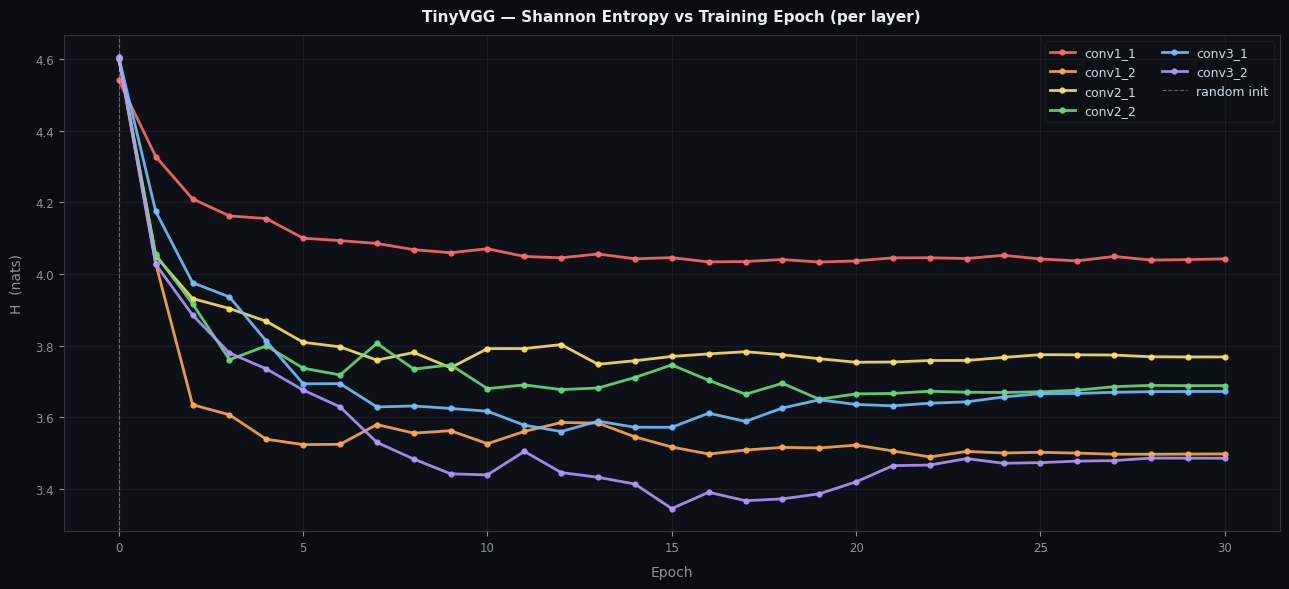

Saved: plot1_entropy_vs_epoch.png


In [14]:
# ================================================================
# CELL 6: Plot 1 — Shannon Entropy vs Epoch (per layer)
# ================================================================
LAYER_COLORS = ['#FF6B6B','#FFA94D','#FFE066','#69DB7C','#74C0FC','#B197FC']
epochs_x     = np.arange(0, EPOCHS+1)

fig, ax = plt.subplots(figsize=(13, 6), facecolor=DARK_BG)

for li, (lname, lc) in enumerate(zip(LAYER_NAMES, LAYER_COLORS)):
    ax.plot(epochs_x, entropy_arr[:, li],
            color=lc, linewidth=2, marker='o', markersize=3.5,
            label=lname, alpha=0.9)

ax.axvline(0, color='white', linewidth=0.8, linestyle='--',
           alpha=0.35, label='random init')

style_ax(ax,
    title='TinyVGG — Shannon Entropy vs Training Epoch (per layer)',
    xlabel='Epoch',
    ylabel='H  (nats)')

ax.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
          facecolor=DARK_BG, edgecolor='#444C56', ncol=2)

plt.tight_layout()
plt.savefig('plot1_entropy_vs_epoch.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: plot1_entropy_vs_epoch.png")

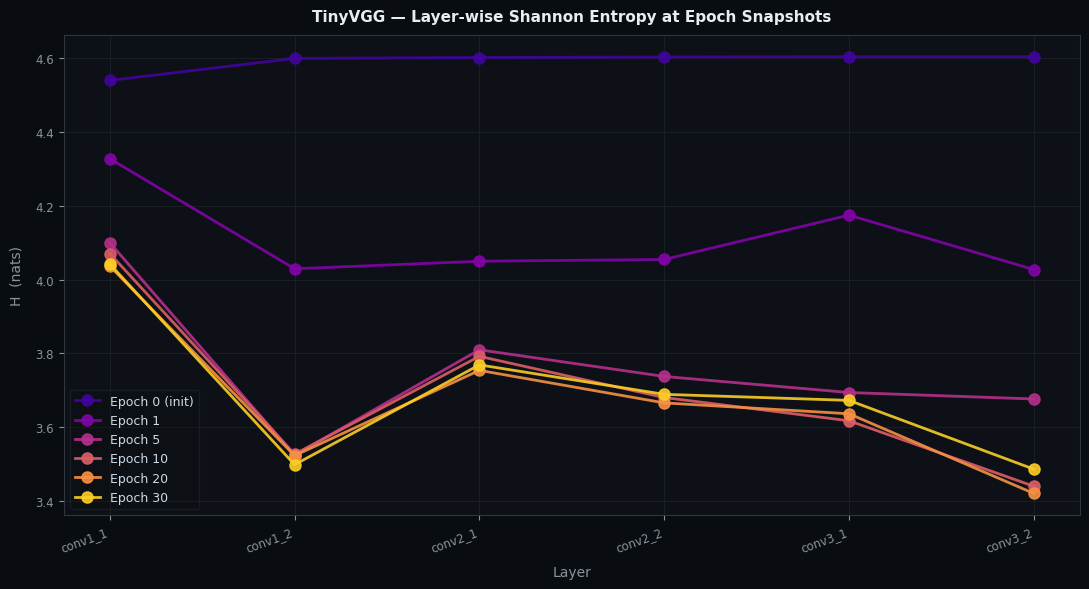

Saved: plot2_layer_entropy_snapshots.png


In [15]:
# ================================================================
# CELL 7: Plot 2 — Layer-wise Entropy at Snapshot Epochs
# ================================================================
import matplotlib.cm as cm

snapshot_epochs = [0, 1, 5, 10, 20, EPOCHS]
snap_colors     = cm.plasma(np.linspace(0.1, 0.9, len(snapshot_epochs)))
x_ticks         = np.arange(N_LAYERS)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=DARK_BG)

for si, ep in enumerate(snapshot_epochs):
    label = f'Epoch {ep}' + (' (init)' if ep == 0 else '')
    ax.plot(x_ticks, entropy_arr[ep],
            color=snap_colors[si], linewidth=2,
            marker='o', markersize=8, label=label, alpha=0.9, zorder=3)

ax.set_xticks(x_ticks)
ax.set_xticklabels(LAYER_NAMES, rotation=20, ha='right',
                   fontsize=9, color=TICK_COL)

style_ax(ax,
    title='TinyVGG — Layer-wise Shannon Entropy at Epoch Snapshots',
    xlabel='Layer',
    ylabel='H  (nats)')

ax.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
          facecolor=DARK_BG, edgecolor='#444C56')

plt.tight_layout()
plt.savefig('plot2_layer_entropy_snapshots.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: plot2_layer_entropy_snapshots.png")

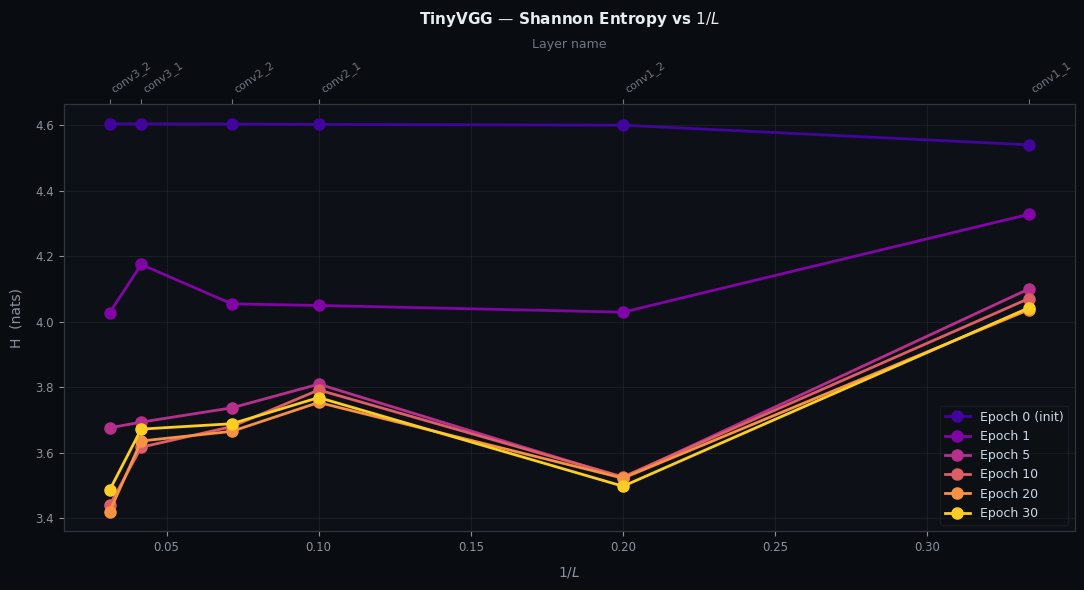

Saved: plot3_entropy_vs_inv_rf.png


In [16]:
# ================================================================
# CELL 8: Plot 3 — Shannon Entropy vs 1/L  (x = increasing 1/L)
# ================================================================
fig, ax = plt.subplots(figsize=(11, 6), facecolor=DARK_BG)

for si, ep in enumerate(snapshot_epochs):
    label = f'Epoch {ep}' + (' (init)' if ep == 0 else '')
    ax.plot(INV_RF, entropy_arr[ep],
            color=snap_colors[si], linewidth=2,
            marker='o', markersize=8, label=label, zorder=3)

# secondary x-axis showing layer names
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(INV_RF)
ax2.set_xticklabels(LAYER_NAMES, rotation=35, ha='left',
                    fontsize=8, color='#6E7681')
ax2.set_xlabel('Layer name', fontsize=9, color='#6E7681', labelpad=8)
ax2.set_facecolor(PANEL_BG)
for sp in ax2.spines.values():
    sp.set_edgecolor('#30363D')
ax2.tick_params(colors='#6E7681')

style_ax(ax,
    title=r'TinyVGG — Shannon Entropy vs $1/L$',
    xlabel=r'$1/L$',
    ylabel='H  (nats)')

ax.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
          facecolor=DARK_BG, edgecolor='#444C56')

plt.tight_layout()
plt.savefig('plot3_entropy_vs_inv_rf.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: plot3_entropy_vs_inv_rf.png")

 Epoch |        α |            C |     R² | Note
───────────────────────────────────────────────────────
Ep   0 |   -0.670 |   4.3042e+00 |  0.943 | 
Ep   1 |   -0.505 |   8.3930e+00 |  0.971 | 
Ep   5 |   -0.313 |   2.3241e+01 |  0.970 | 
Ep  10 |   -0.394 |   2.3901e+01 |  0.954 | 
Ep  20 |   -0.469 |   2.0755e+01 |  0.945 | 
Ep  30 |   -0.475 |   1.9358e+01 |  0.945 | 


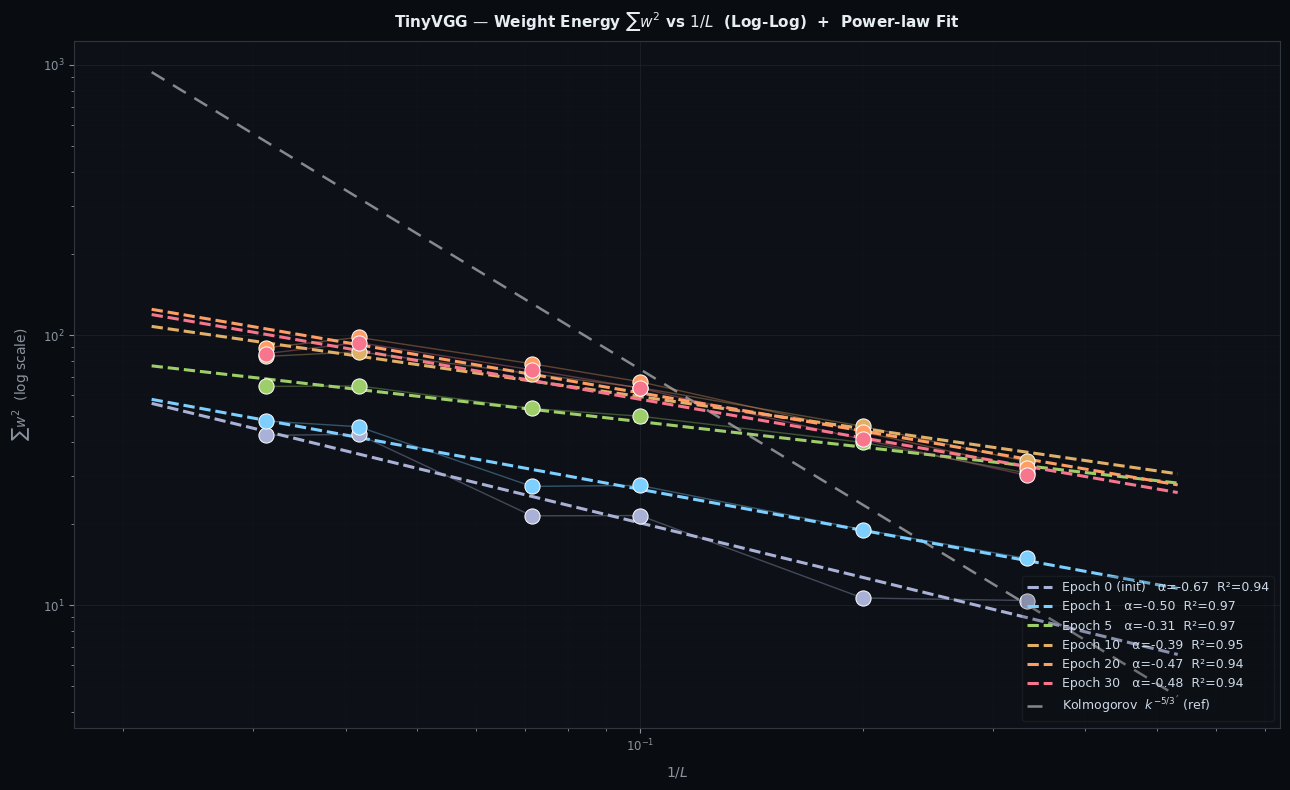

Saved: plot4_sumSq_powerlaw.png


In [17]:
# ================================================================
# CELL 9: Plot 4 — Sum(w²) vs 1/L  Log-Log + Power-law fits
# ================================================================
snap_colors_dict = {
    0:      '#A9B1D6',
    1:      '#7DCFFF',
    5:      '#9ECE6A',
    10:     '#E0AF68',
    20:     '#FF9E64',
    EPOCHS: '#F7768E',
}

x_dense = np.logspace(np.log10(INV_RF.min()*0.7),
                       np.log10(INV_RF.max()*1.6), 400)

# ── Compute fits ──
fit_results = {}
print(f"{'Epoch':>6} | {'α':>8} | {'C':>12} | {'R²':>6} | Note")
print("─"*55)
for ep in snapshot_epochs:
    lx = np.log10(INV_RF)
    ly = np.log10(sum_sq_arr[ep] + 1e-12)
    slope, intercept, r, *_ = linregress(lx, ly)
    C  = 10**intercept
    fit_results[ep] = (slope, C, r**2)
    note = '≈ Kolmogorov!' if abs(slope + 5/3) < 0.25 else ''
    print(f"Ep {ep:>3d} | {slope:>8.3f} | {C:>12.4e} | {r**2:>6.3f} | {note}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(13, 8), facecolor=DARK_BG)
ax.set_facecolor(PANEL_BG)

for ep in snapshot_epochs:
    fc    = snap_colors_dict[ep]
    label = f'Epoch {ep}' + (' (init)' if ep == 0 else '')
    slope, C, r2 = fit_results[ep]

    ax.scatter(INV_RF, sum_sq_arr[ep],
               color=fc, s=120, zorder=5,
               edgecolors='white', linewidths=0.7)
    ax.plot(INV_RF, sum_sq_arr[ep],
            color=fc, linewidth=1.0, alpha=0.35, zorder=4)
    ax.plot(x_dense, C * x_dense**slope,
            color=fc, linewidth=2.2, linestyle='--', zorder=3,
            label=f'{label}   α={slope:.2f}  R²={r2:.2f}')

# Kolmogorov reference
y_final  = sum_sq_arr[EPOCHS]
x_anchor = np.exp(np.mean(np.log(INV_RF)))
y_anchor = np.exp(np.interp(np.log(x_anchor),
                             np.log(INV_RF),
                             np.log(y_final + 1e-12)))
ax.plot(x_dense, y_anchor * (x_dense/x_anchor)**(-5/3),
        color='white', linewidth=1.8,
        linestyle=(0,(6,4)), alpha=0.5, zorder=2,
        label=r'Kolmogorov  $k^{-5/3}$  (ref)')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(INV_RF.min()*0.55, INV_RF.max()*2.2)
ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation())
ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation())

style_ax(ax,
    title=r'TinyVGG — Weight Energy $\sum w^2$ vs $1/L$  (Log-Log)  +  Power-law Fit',
    xlabel=r'$1/L$',
    ylabel=r'$\sum w^2$  (log scale)')

ax.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
          facecolor=DARK_BG, edgecolor='#444C56',
          loc='lower right')

plt.tight_layout()
plt.savefig('plot4_sumSq_powerlaw.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: plot4_sumSq_powerlaw.png")

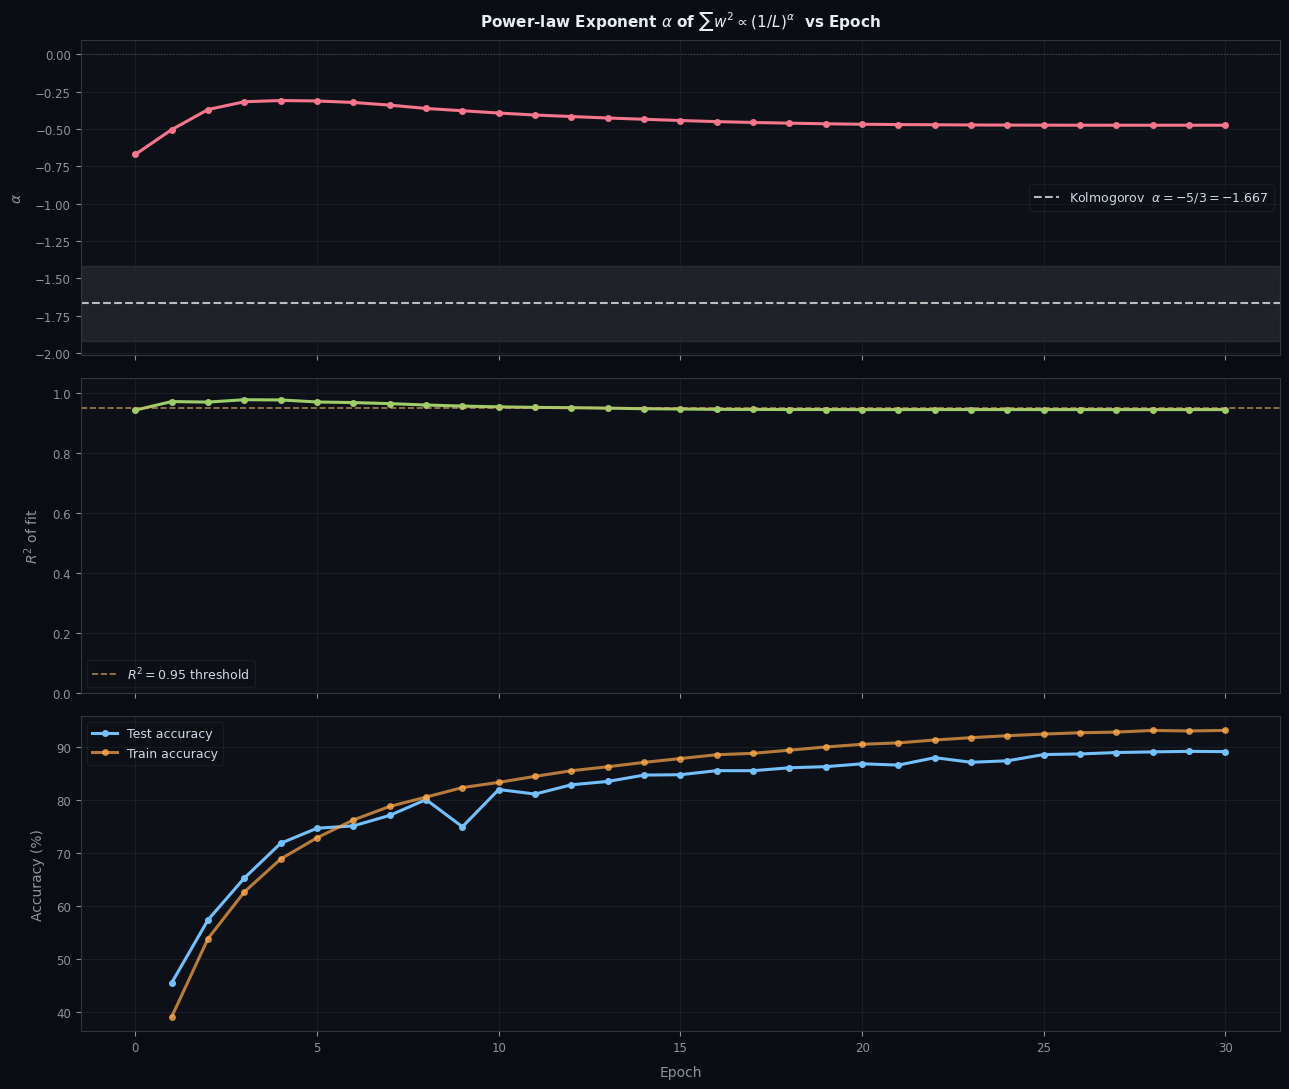

Saved: plot5_alpha_evolution.png


In [18]:
# ================================================================
# CELL 10: Plot 5 — Power-law exponent α across all epochs
# ================================================================
all_alphas, all_r2 = [], []

for ep in range(EPOCHS+1):
    lx = np.log10(INV_RF)
    ly = np.log10(sum_sq_arr[ep] + 1e-12)
    slope, _, r, *_ = linregress(lx, ly)
    all_alphas.append(slope)
    all_r2.append(r**2)

epochs_x = np.arange(EPOCHS+1)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 11),
                                     facecolor=DARK_BG, sharex=True)

# ── Panel 1: α vs epoch ──
ax1.plot(epochs_x, all_alphas,
         color='#F7768E', linewidth=2.2, marker='o', markersize=4)
ax1.axhline(-5/3, color='white', linewidth=1.5, linestyle='--',
            alpha=0.7, label=r'Kolmogorov  $\alpha=-5/3=-1.667$')
ax1.axhspan(-5/3-0.25, -5/3+0.25,
            alpha=0.08, color='white')
ax1.axhline(0, color='#444C56', linewidth=0.8, linestyle=':')
style_ax(ax1,
    title=r'Power-law Exponent $\alpha$ of $\sum w^2 \propto (1/L)^\alpha$  vs Epoch',
    ylabel=r'$\alpha$')
ax1.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
           facecolor=DARK_BG, edgecolor='#444C56')

# ── Panel 2: R² vs epoch ──
ax2.plot(epochs_x, all_r2,
         color='#9ECE6A', linewidth=2.2, marker='o', markersize=4)
ax2.axhline(0.95, color='#E0AF68', linewidth=1.2, linestyle='--',
            alpha=0.7, label=r'$R^2 = 0.95$ threshold')
ax2.set_ylim(0, 1.05)
style_ax(ax2, ylabel=r'$R^2$ of fit')
ax2.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
           facecolor=DARK_BG, edgecolor='#444C56')

# ── Panel 3: Test accuracy ──
ax3.plot(range(1, EPOCHS+1), test_acc_log,
         color='#74C0FC', linewidth=2.2, marker='o', markersize=4,
         label='Test accuracy')
ax3.plot(range(1, EPOCHS+1), train_acc_log,
         color='#FFA94D', linewidth=2.2, marker='o', markersize=4,
         label='Train accuracy', alpha=0.7)
style_ax(ax3,
    xlabel='Epoch',
    ylabel='Accuracy (%)')
ax3.legend(fontsize=9, framealpha=0.2, labelcolor=TEXT_COL,
           facecolor=DARK_BG, edgecolor='#444C56')

plt.tight_layout()
plt.savefig('plot5_alpha_evolution.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: plot5_alpha_evolution.png")

In [19]:
# ================================================================
# CELL 11: Summary Table — all metrics at snapshot epochs
# ================================================================
print("="*80)
print("SUMMARY: Shannon Entropy per layer at snapshot epochs")
print("="*80)
print(f"{'Epoch':>6} | " + " | ".join(f"{n:>10}" for n in LAYER_NAMES))
print("─"*80)
for ep in snapshot_epochs:
    row = " | ".join(f"{entropy_arr[ep,li]:>10.4f}" for li in range(N_LAYERS))
    print(f"Ep {ep:>3d} | {row}")

print("\n" + "="*80)
print("SUMMARY: Sum(w²) per layer at snapshot epochs")
print("="*80)
print(f"{'Epoch':>6} | " + " | ".join(f"{n:>10}" for n in LAYER_NAMES))
print("─"*80)
for ep in snapshot_epochs:
    row = " | ".join(f"{sum_sq_arr[ep,li]:>10.2f}" for li in range(N_LAYERS))
    print(f"Ep {ep:>3d} | {row}")

print("\n" + "="*80)
print("SUMMARY: Power-law fit α at snapshot epochs")
print("="*80)
print(f"{'Epoch':>6} | {'α':>8} | {'R²':>6} | Distance from Kolmogorov (-5/3)")
print("─"*55)
for ep in snapshot_epochs:
    slope, _, r2 = fit_results[ep]
    dist = abs(slope - (-5/3))
    bar  = '█' * int(max(0, 10 - dist*6))
    print(f"Ep {ep:>3d} | {slope:>8.3f} | {r2:>6.3f} | Δ={dist:.3f}  {bar}")

SUMMARY: Shannon Entropy per layer at snapshot epochs
 Epoch |    conv1_1 |    conv1_2 |    conv2_1 |    conv2_2 |    conv3_1 |    conv3_2
────────────────────────────────────────────────────────────────────────────────
Ep   0 |     4.5403 |     4.6002 |     4.6026 |     4.6040 |     4.6046 |     4.6047
Ep   1 |     4.3280 |     4.0293 |     4.0497 |     4.0546 |     4.1748 |     4.0272
Ep   5 |     4.1000 |     3.5237 |     3.8095 |     3.7371 |     3.6935 |     3.6759
Ep  10 |     4.0706 |     3.5262 |     3.7917 |     3.6799 |     3.6168 |     3.4391
Ep  20 |     4.0366 |     3.5222 |     3.7536 |     3.6653 |     3.6359 |     3.4197
Ep  30 |     4.0423 |     3.4977 |     3.7685 |     3.6886 |     3.6721 |     3.4855

SUMMARY: Sum(w²) per layer at snapshot epochs
 Epoch |    conv1_1 |    conv1_2 |    conv2_1 |    conv2_2 |    conv3_1 |    conv3_2
────────────────────────────────────────────────────────────────────────────────
Ep   0 |      10.39 |      10.62 |      21.45 |      21.4